# CTA Multi-Asset Trend Following & Derivatives Overlay

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import yaml, warnings, time
from datetime import datetime, timedelta
warnings.filterwarnings('ignore')

from massive import RESTClient

plt.rcParams.update({
    'figure.figsize': (14, 5), 'font.size': 10,
    'font.sans-serif': ['Arial Unicode MS', 'SimHei'],
    'axes.unicode_minus': False, 'figure.dpi': 110
})

with open('../data_preparation/data_apiKey/config.yaml') as f:
    cfg = yaml.safe_load(f)
client = RESTClient(api_key=cfg['keys']['polygon_api_key'])

START, END = '2019-06-01', '2025-02-28'
VOL_TGT = 0.10
TC_BPS = 5

## 1. Multi-Asset Universe — Price Data

**Equity / Commodity / Bond ETFs** via `list_aggs()` + **G10 FX** via forex aggs (`C:XXXX` tickers)

In [2]:
etf_tickers = {
    'SPY': 'US Equity', 'QQQ': 'US Tech', 'EFA': 'Intl Equity', 'EEM': 'EM Equity',
    'TLT': 'Long Bond', 'IEF': 'Mid Bond',
    'GLD': 'Gold', 'SLV': 'Silver', 'USO': 'Crude Oil', 'DBA': 'Agriculture', 'DBC': 'Broad Cmdty',
    'UNG': 'Nat Gas',
}
fx_tickers = {'C:EURUSD': 'EURUSD', 'C:GBPUSD': 'GBPUSD', 'C:USDJPY': 'USDJPY',
              'C:AUDUSD': 'AUDUSD', 'C:USDCAD': 'USDCAD', 'C:NZDUSD': 'NZDUSD'}

def fetch_aggs(ticker, start=START, end=END):
    bars = list(client.list_aggs(ticker, 1, 'day', start, end, limit=50000))
    df = pd.DataFrame([{
        'date': pd.Timestamp(b.timestamp, unit='ms').normalize(),
        'open': b.open, 'high': b.high, 'low': b.low, 'close': b.close, 'volume': b.volume
    } for b in bars])
    return df.set_index('date').sort_index()

prices = {}
for t in list(etf_tickers) + list(fx_tickers):
    try:
        d = fetch_aggs(t)
        prices[t] = d['close']
        time.sleep(0.15)
    except Exception as e:
        print(f'{t}: {e}')

px = pd.DataFrame(prices).ffill().dropna(how='all')
px.columns = [etf_tickers.get(c, fx_tickers.get(c, c)) for c in px.columns]
print(f'universe: {px.shape[1]} assets, {px.shape[0]} days, {px.index[0].date()} → {px.index[-1].date()}')
px.tail(3)

C:NZDUSD: HTTPSConnectionPool(host='api.massive.com', port=443): Max retries exceeded with url: /v2/aggs/ticker/C:NZDUSD/range/1/day/2019-06-01/2025-02-28?limit=50000 (Caused by ResponseError('too many 429 error responses'))
universe: 17 assets, 1506 days, 2019-06-03 → 2025-02-28


,US Equity,US Tech,Intl Equity,EM Equity,Long Bond,Mid Bond,Gold,Silver,Crude Oil,Agriculture,Broad Cmdty,Nat Gas,EURUSD,GBPUSD,USDJPY,AUDUSD,USDCAD
date,,,,,,,,,,,,,,,,,
2025-02-26,594.54,514.56,82.34,44.68,91.96,94.91,269.03,28.94,73.85,27.12,22.14,21.15,1.04874,1.26801,148.871,0.63088,1.43378
2025-02-27,585.05,500.27,81.41,43.81,91.31,94.80,264.93,28.40,75.28,26.81,22.17,20.86,1.03930,1.25959,150.084,0.62312,1.44462
2025-02-28,594.18,508.17,81.58,43.21,92.43,95.32,263.27,28.31,75.22,26.49,22.00,20.34,1.03740,1.25780,150.618,0.62032,1.44630


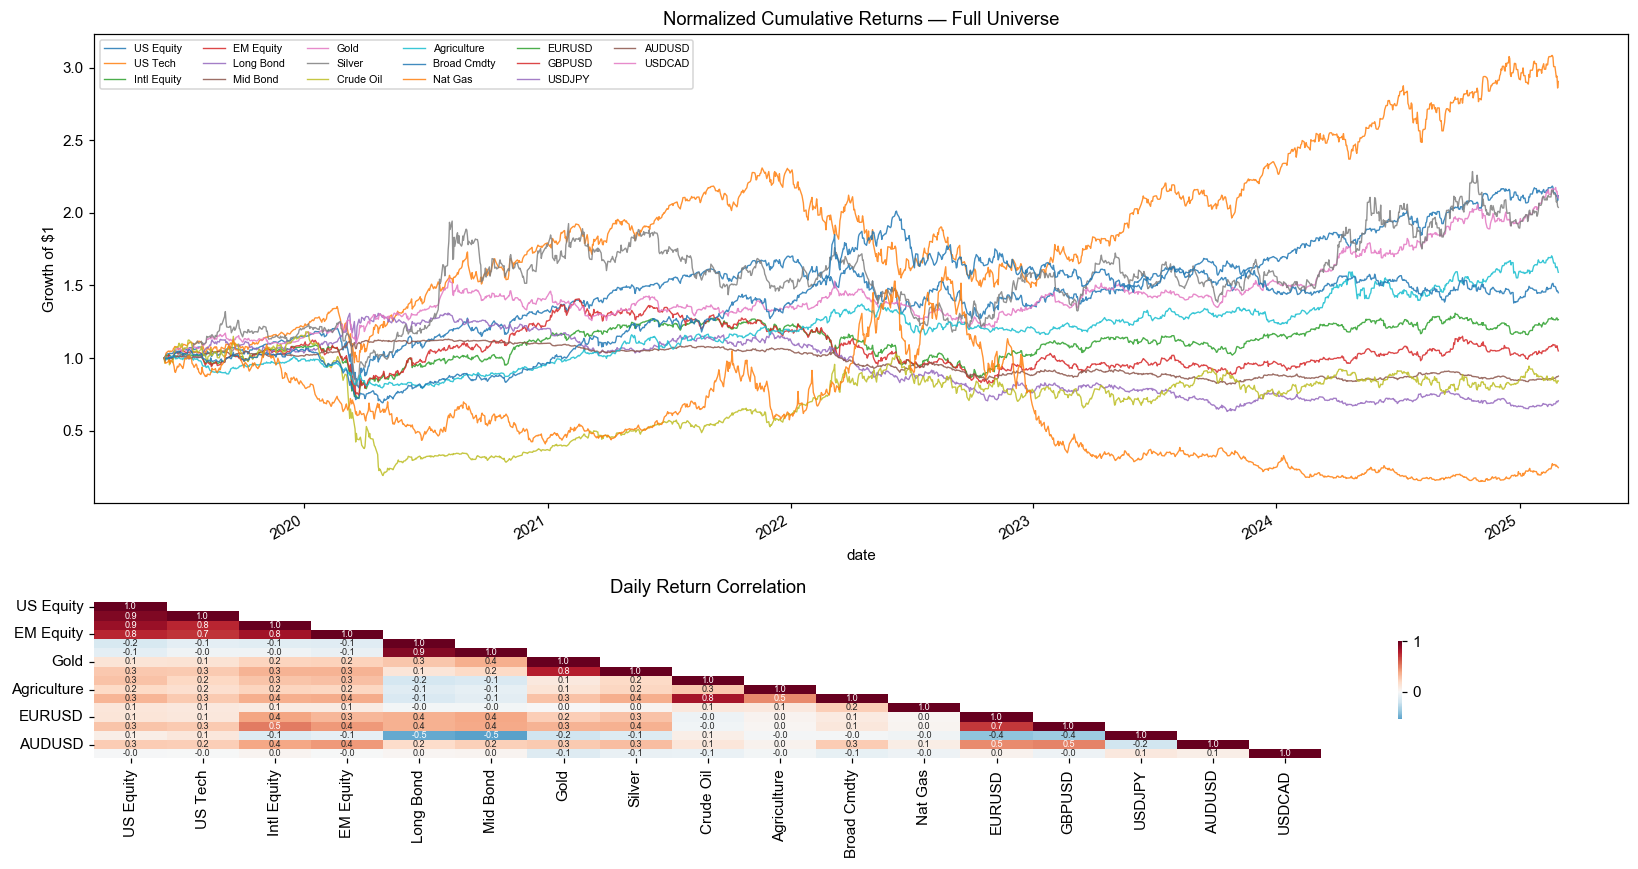

In [3]:
ret = px.pct_change().dropna(how='all')
cum = (1 + ret).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(15, 8), gridspec_kw={'height_ratios': [3, 1]})
(cum / cum.iloc[0]).plot(ax=axes[0], lw=0.9, alpha=0.85)
axes[0].set_title('Normalized Cumulative Returns — Full Universe')
axes[0].legend(fontsize=7, ncol=6, loc='upper left')
axes[0].set_ylabel('Growth of $1')

corr = ret.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, ax=axes[1],
            annot=True, fmt='.1f', annot_kws={'size': 6}, cbar_kws={'shrink': 0.5})
axes[1].set_title('Daily Return Correlation')
plt.tight_layout()
plt.show()

## 2. Macro Regime — Treasury Yields & Indicators

Fed treasury yield data via `list_treasury_yields()` economy endpoint. Regime: **risk-on** (2s10s spread > 0 or flattening from inversion) vs **risk-off** (deep inversion).

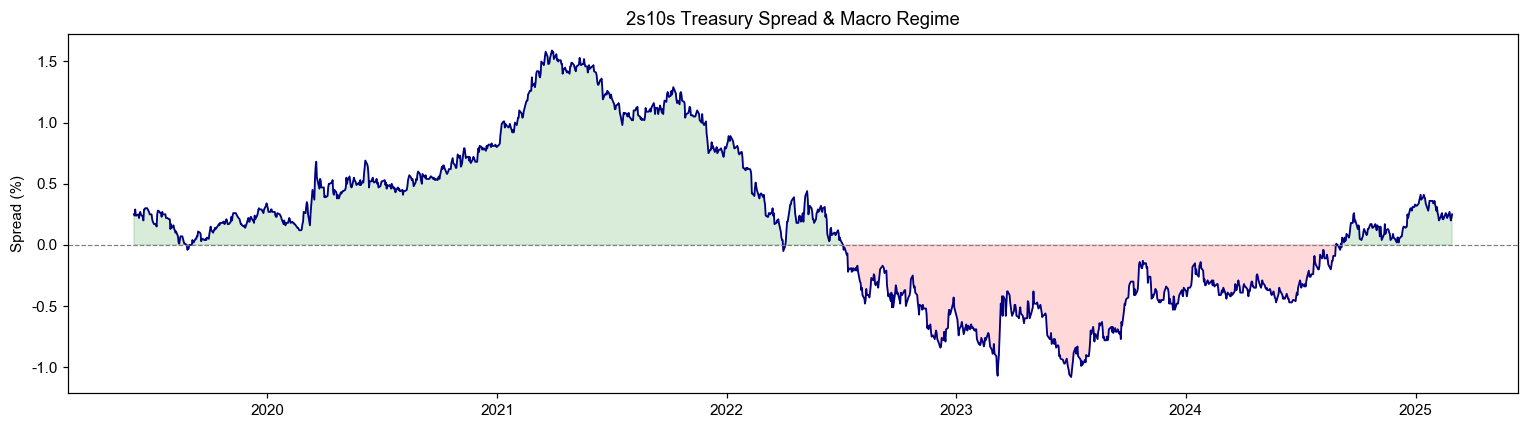

regime
neutral     594
risk_off    430
risk_on     413
Name: count, dtype: int64


In [4]:
yields_raw = list(client.list_treasury_yields(
    date_gte=START, date_lte=END, limit=50000, sort='date', order='asc'
))

yld_pivot = pd.DataFrame([{
    'date': pd.Timestamp(y.date),
    '1m': y.yield_1_month, '3m': y.yield_3_month, '6m': y.yield_6_month,
    '1y': y.yield_1_year, '2y': y.yield_2_year, '3y': y.yield_3_year,
    '5y': y.yield_5_year, '7y': y.yield_7_year, '10y': y.yield_10_year,
    '20y': y.yield_20_year, '30y': y.yield_30_year,
} for y in yields_raw]).set_index('date').sort_index().ffill()

spread_2s10s = yld_pivot['10y'] - yld_pivot['2y']
spread_2s10s.name = '2s10s'

regime = pd.Series('neutral', index=spread_2s10s.index, name='regime')
regime[spread_2s10s > 0.5] = 'risk_on'
regime[spread_2s10s < -0.3] = 'risk_off'
regime_score = regime.map({'risk_on': 1.0, 'neutral': 0.7, 'risk_off': 0.4})

fig, ax1 = plt.subplots(figsize=(14, 4))
ax1.plot(spread_2s10s.index, spread_2s10s.values, color='navy', lw=1.2)
ax1.axhline(0, color='grey', ls='--', lw=0.8)
ax1.fill_between(spread_2s10s.index, spread_2s10s.values, 0,
                 where=spread_2s10s > 0, alpha=0.15, color='green')
ax1.fill_between(spread_2s10s.index, spread_2s10s.values, 0,
                 where=spread_2s10s < 0, alpha=0.15, color='red')
ax1.set_title('2s10s Treasury Spread & Macro Regime')
ax1.set_ylabel('Spread (%)')
plt.tight_layout()
plt.show()

print(regime.value_counts())

## 3. Technical Indicators from API

RSI (14d) and MACD (12/26/9) pulled directly from Massive `get_rsi()` / `get_macd()` indicator endpoints — used as trend confirmation filters.

RSI: (1445, 12), MACD hist: (1445, 12)


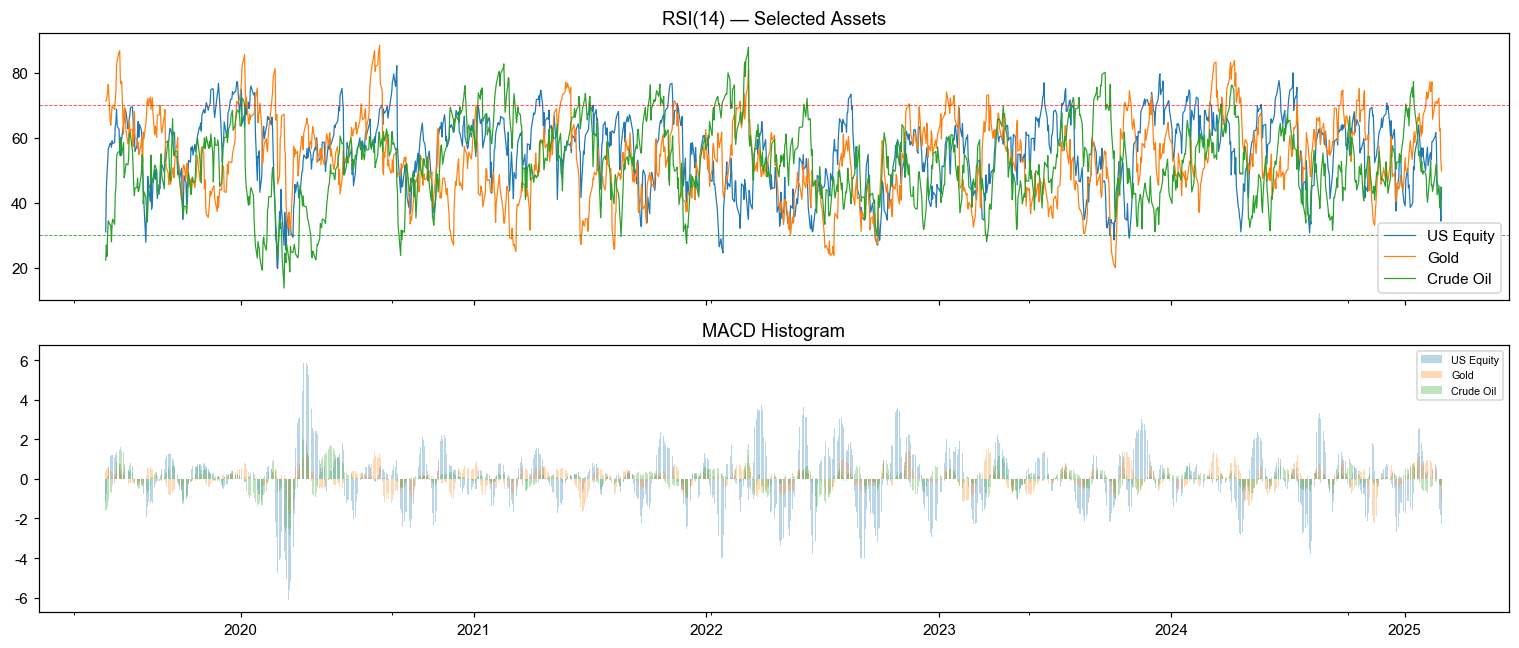

In [5]:
etf_only = list(etf_tickers.keys())

rsi_data, macd_data = {}, {}
for t in etf_only:
    try:
        rsi_res = client.get_rsi(t, timespan='day', window=14,
                                 series_type='close', order='asc', limit=5000,
                                 timestamp_gte=START, timestamp_lte=END)
        rsi_vals = rsi_res.values if hasattr(rsi_res, 'values') else []
        if rsi_vals:
            rsi_data[etf_tickers[t]] = pd.Series(
                {pd.Timestamp(v.timestamp, unit='ms').normalize(): v.value for v in rsi_vals}
            )

        macd_res = client.get_macd(t, timespan='day', short_window=12, long_window=26,
                                   signal_window=9, series_type='close', order='asc', limit=5000,
                                   timestamp_gte=START, timestamp_lte=END)
        macd_vals = macd_res.values if hasattr(macd_res, 'values') else []
        if macd_vals:
            macd_data[etf_tickers[t]] = pd.Series(
                {pd.Timestamp(v.timestamp, unit='ms').normalize(): v.histogram for v in macd_vals}
            )
        time.sleep(0.25)
    except Exception as e:
        print(f'{t}: {e}')

df_rsi = pd.DataFrame(rsi_data)
df_macd_hist = pd.DataFrame(macd_data)
print(f'RSI: {df_rsi.shape}, MACD hist: {df_macd_hist.shape}')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
if not df_rsi.empty:
    df_rsi[['US Equity', 'Gold', 'Crude Oil']].dropna().plot(ax=ax1, lw=0.8)
    ax1.axhline(70, color='r', ls='--', lw=0.6, alpha=0.7)
    ax1.axhline(30, color='g', ls='--', lw=0.6, alpha=0.7)
    ax1.set_title('RSI(14) — Selected Assets')
if not df_macd_hist.empty:
    for col in ['US Equity', 'Gold', 'Crude Oil']:
        if col in df_macd_hist:
            ax2.bar(df_macd_hist.index, df_macd_hist[col], alpha=0.3, width=1, label=col)
    ax2.set_title('MACD Histogram')
    ax2.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 4. Signal Construction

Three classic CTA signals combined:
1. **TSMOM** — 12-month return, skip last month (Moskowitz, Ooi, Pedersen 2012)
2. **Donchian Breakout** — 60-day high/low channel
3. **EWMAC** — Exponential moving average crossover (fast 16d / slow 64d)

Indicator overlay: RSI ∈ (30, 70) confirms trend; MACD histogram sign aligns with position direction.

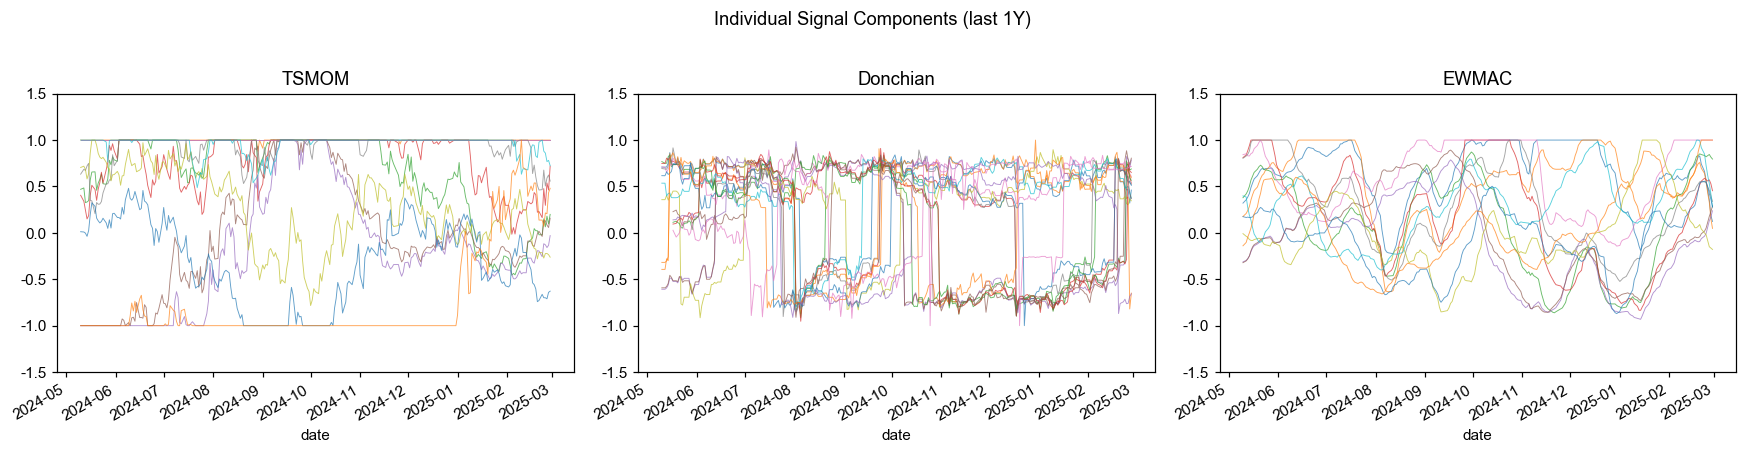

In [6]:
def tsmom_signal(prices, lookback=252, skip=21):
    past_ret = prices.pct_change(lookback).shift(skip)
    vol = past_ret.rolling(252, min_periods=60).std()
    z = past_ret / vol.replace(0, np.nan)
    return z.clip(-2, 2) / 2

def donchian_signal(prices, window=60):
    high_ch = prices.shift(1).rolling(window).max()
    low_ch = prices.shift(1).rolling(window).min()
    mid = (high_ch + low_ch) / 2
    rng = (high_ch - low_ch).replace(0, np.nan)
    sig = pd.DataFrame(np.nan, index=prices.index, columns=prices.columns)
    sig[prices > high_ch] = 1.0
    sig[prices < low_ch] = -1.0
    sig = sig.ffill().fillna(0)
    blend = ((prices - mid) / rng).clip(-1, 1)
    return 0.5 * sig + 0.5 * blend

def ewmac_signal(prices, fast=16, slow=64):
    ema_f = prices.ewm(span=fast, min_periods=fast).mean()
    ema_s = prices.ewm(span=slow, min_periods=slow).mean()
    raw = ema_f - ema_s
    return raw.apply(lambda x: x / x.rolling(252).std())

sig_tsmom = tsmom_signal(px)
sig_donch = donchian_signal(px)
sig_ewmac = ewmac_signal(px).clip(-2, 2) / 2

rsi_filter = pd.DataFrame(1.0, index=px.index, columns=px.columns)
if not df_rsi.empty:
    rsi_al = df_rsi.reindex(px.index).reindex(columns=px.columns)
    rsi_filter[(rsi_al > 75)] = 0.5
    rsi_filter[(rsi_al < 25)] = 0.5

macd_filter = pd.DataFrame(1.0, index=px.index, columns=px.columns)
if not df_macd_hist.empty:
    macd_al = df_macd_hist.reindex(px.index).reindex(columns=px.columns)
    macd_sign = np.sign(macd_al.fillna(0))
    combined_dir = np.sign(sig_tsmom.fillna(0) + sig_ewmac.fillna(0))
    disagree = (macd_sign != 0) & (combined_dir != 0) & (macd_sign != combined_dir)
    macd_filter[disagree] = 0.5
n_active = (sig_tsmom.notna().astype(int) + sig_donch.notna().astype(int) + sig_ewmac.notna().astype(int)).replace(0, 1)
wt_tsmom = (0.4 * sig_tsmom.notna().astype(float)) / n_active * (n_active / 0.4).clip(upper=1/0.4)
raw_signal = (0.4 * sig_tsmom.fillna(0) + 0.3 * sig_donch.fillna(0) + 0.3 * sig_ewmac.fillna(0))

avail_wt = 0.4 * sig_tsmom.notna().astype(float) + 0.3 * sig_donch.notna().astype(float) + 0.3 * sig_ewmac.notna().astype(float)
raw_signal = raw_signal / avail_wt.replace(0, 1)
raw_signal = (raw_signal * rsi_filter * macd_filter).clip(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, sig) in zip(axes, [('TSMOM', sig_tsmom), ('Donchian', sig_donch), ('EWMAC', sig_ewmac)]):
    sig.dropna(how='all').iloc[-252:].plot(ax=ax, lw=0.6, legend=False, alpha=0.7)
    ax.set_title(name)
    ax.set_ylim(-1.5, 1.5)
plt.suptitle('Individual Signal Components (last 1Y)', y=1.02)
plt.tight_layout()
plt.show()

## 5. Volatility Targeting & Position Sizing

Each asset scaled to contribute `σ_target / N` risk. Realized vol estimated via exponentially-weighted 60-day window. Macro regime score further scales gross exposure.

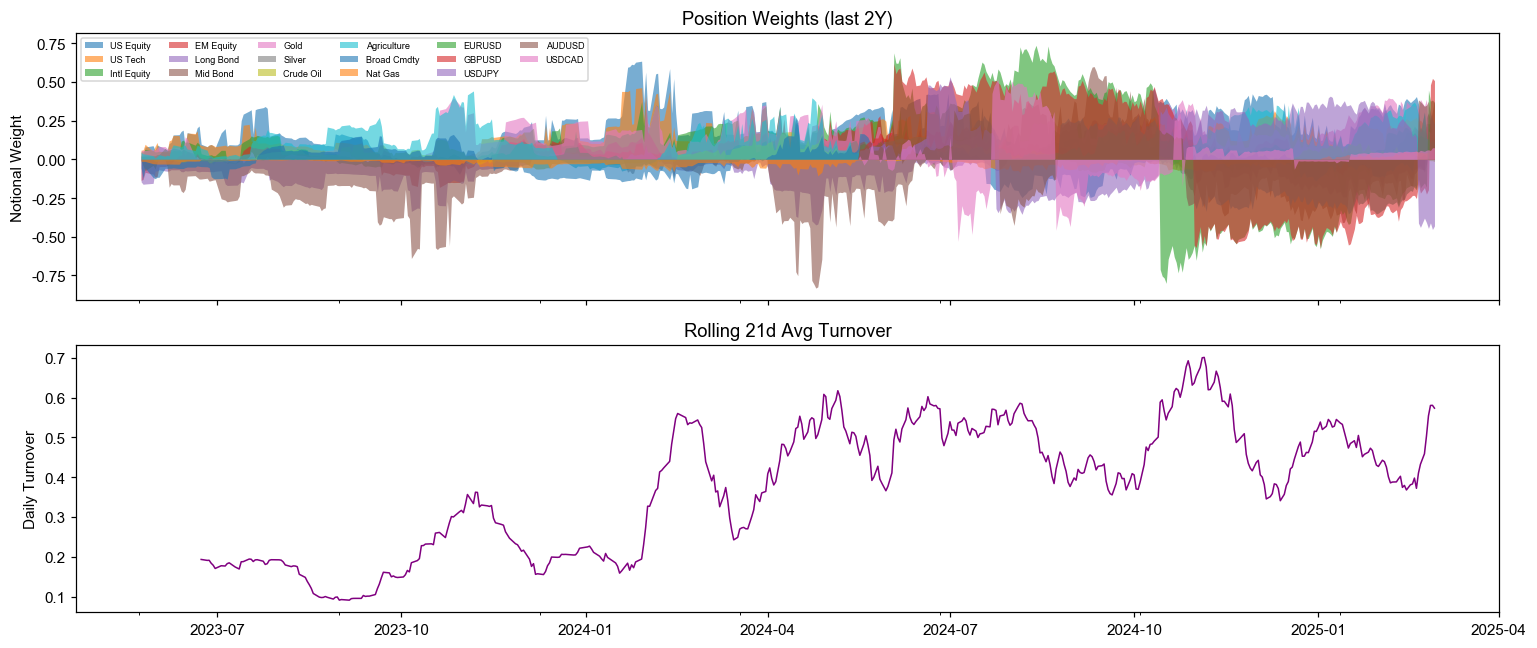

avg daily turnover: 0.303
avg gross exposure: 1.93
avg net exposure:   0.70


In [7]:
realized_vol = ret.ewm(span=60, min_periods=30).std() * np.sqrt(252)

vol_scalar = (VOL_TGT / realized_vol.replace(0, np.nan)).clip(0, 4)

regime_al = regime_score.reindex(px.index).ffill().fillna(0.7)

positions = raw_signal * vol_scalar * regime_al.values[:, None]
positions = positions.fillna(0)

gross_exp = positions.abs().sum(axis=1)
cap = 3.0
positions = positions.div(gross_exp.clip(lower=cap), axis=0) * cap
positions[gross_exp <= cap] = (raw_signal * vol_scalar * regime_al.values[:, None]).fillna(0)[gross_exp <= cap]

turnover = positions.diff().abs().sum(axis=1)
tc_drag = turnover * TC_BPS / 10000

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
positions.iloc[-504:].plot.area(ax=ax1, lw=0, alpha=0.6, stacked=False)
ax1.set_title('Position Weights (last 2Y)')
ax1.legend(fontsize=6, ncol=6, loc='upper left')
ax1.set_ylabel('Notional Weight')

ax2.plot(turnover.iloc[-504:].rolling(21).mean(), color='purple', lw=1)
ax2.set_title('Rolling 21d Avg Turnover')
ax2.set_ylabel('Daily Turnover')
plt.tight_layout()
plt.show()

print(f'avg daily turnover: {turnover.mean():.3f}')
print(f'avg gross exposure: {positions.abs().sum(axis=1).mean():.2f}')
print(f'avg net exposure:   {positions.sum(axis=1).mean():.2f}')

## 6. Backtest

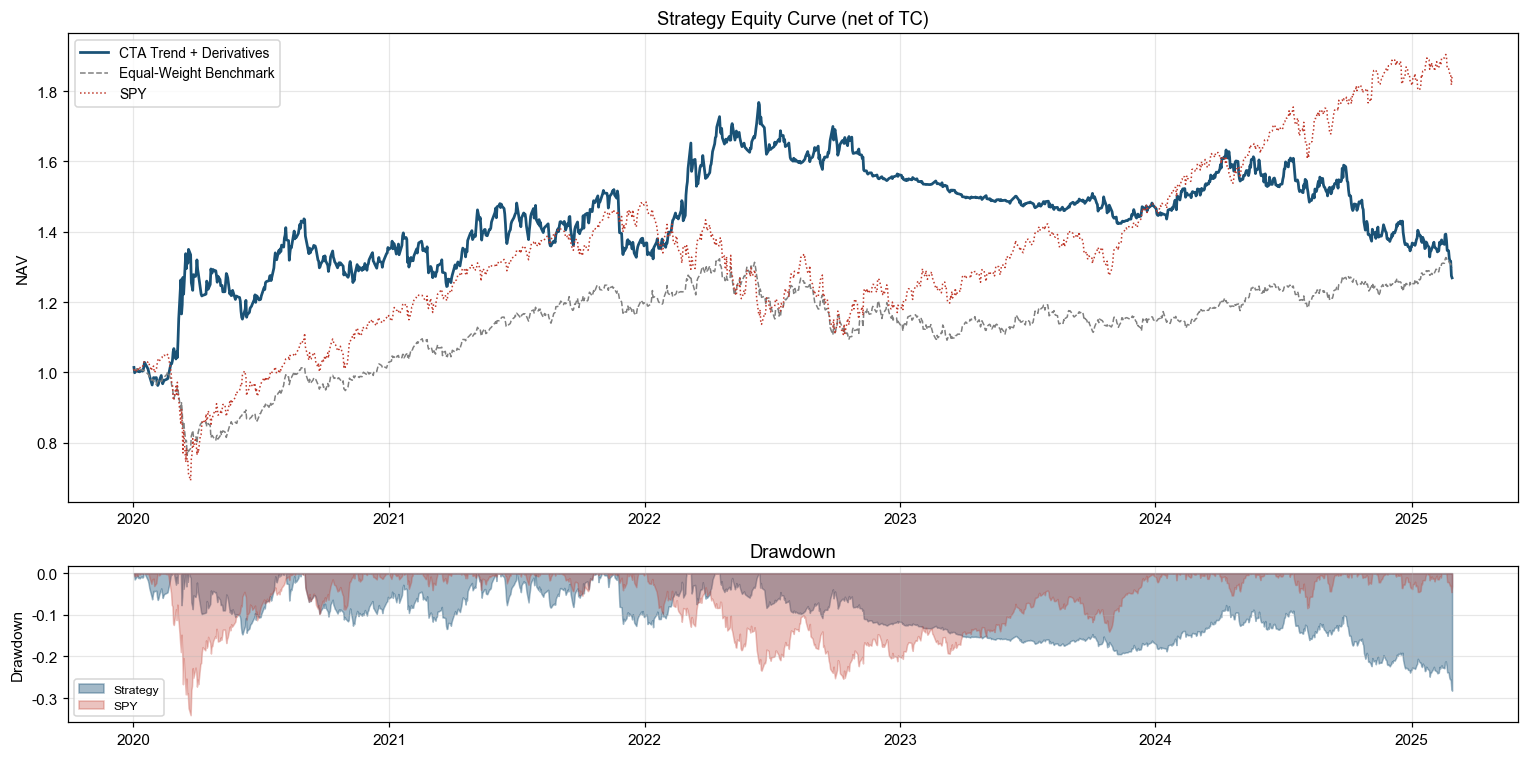

In [8]:
strat_ret = (positions.shift(1) * ret).sum(axis=1) - tc_drag
strat_ret = strat_ret.loc[strat_ret.index >= '2020-01-01']

eq_wt_ret = ret.mean(axis=1).loc[strat_ret.index]
spy_ret = ret[px.columns[0]].loc[strat_ret.index] if px.columns[0] in ret else eq_wt_ret

nav_strat = (1 + strat_ret).cumprod()
nav_eq = (1 + eq_wt_ret).cumprod()
nav_spy = (1 + spy_ret).cumprod()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(nav_strat, label='CTA Trend + Derivatives', color='#1a5276', lw=1.8)
ax1.plot(nav_eq, label='Equal-Weight Benchmark', color='grey', lw=1, ls='--')
ax1.plot(nav_spy, label='SPY', color='#c0392b', lw=1, ls=':')
ax1.set_title('Strategy Equity Curve (net of TC)')
ax1.legend(fontsize=9)
ax1.set_ylabel('NAV')
ax1.grid(alpha=0.3)

dd_strat = nav_strat / nav_strat.cummax() - 1
dd_spy = nav_spy / nav_spy.cummax() - 1
ax2.fill_between(dd_strat.index, dd_strat.values, 0, alpha=0.4, color='#1a5276', label='Strategy')
ax2.fill_between(dd_spy.index, dd_spy.values, 0, alpha=0.3, color='#c0392b', label='SPY')
ax2.set_title('Drawdown')
ax2.legend(fontsize=8)
ax2.set_ylabel('Drawdown')
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
def perf_stats(r, name='Strategy', rf=0.0):
    ann_ret = r.mean() * 252
    ann_vol = r.std() * np.sqrt(252)
    sharpe = (ann_ret - rf) / ann_vol if ann_vol > 0 else 0
    nav = (1 + r).cumprod()
    dd = nav / nav.cummax() - 1
    max_dd = dd.min()
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0
    sortino = (ann_ret - rf) / (r[r < 0].std() * np.sqrt(252)) if (r < 0).any() else 0
    skew = r.skew()
    kurt = r.kurtosis()
    win_rate = (r > 0).mean()
    return pd.Series({
        'Ann Return': f'{ann_ret:.2%}', 'Ann Vol': f'{ann_vol:.2%}',
        'Sharpe': f'{sharpe:.2f}', 'Sortino': f'{sortino:.2f}',
        'Calmar': f'{calmar:.2f}', 'Max DD': f'{max_dd:.2%}',
        'Skew': f'{skew:.2f}', 'Kurtosis': f'{kurt:.2f}',
        'Win Rate': f'{win_rate:.1%}', 'Worst Day': f'{r.min():.2%}',
        'Best Day': f'{r.max():.2%}'
    }, name=name)

summary = pd.concat([
    perf_stats(strat_ret, 'CTA Trend'),
    perf_stats(eq_wt_ret, 'Equal Wt'),
    perf_stats(spy_ret, 'SPY')
], axis=1)
summary

,CTA Trend,Equal Wt,SPY
Ann Return,6.15%,5.71%,13.47%
Ann Vol,18.63%,13.26%,20.40%
Sharpe,0.33,0.43,0.66
Sortino,0.44,0.53,0.79
Calmar,0.22,0.23,0.39
Max DD,-28.22%,-24.32%,-34.10%
Skew,0.27,-0.89,-0.55
Kurtosis,10.44,7.43,12.13
Win Rate,51.4%,54.9%,52.3%
Worst Day,-7.68%,-6.59%,-10.94%


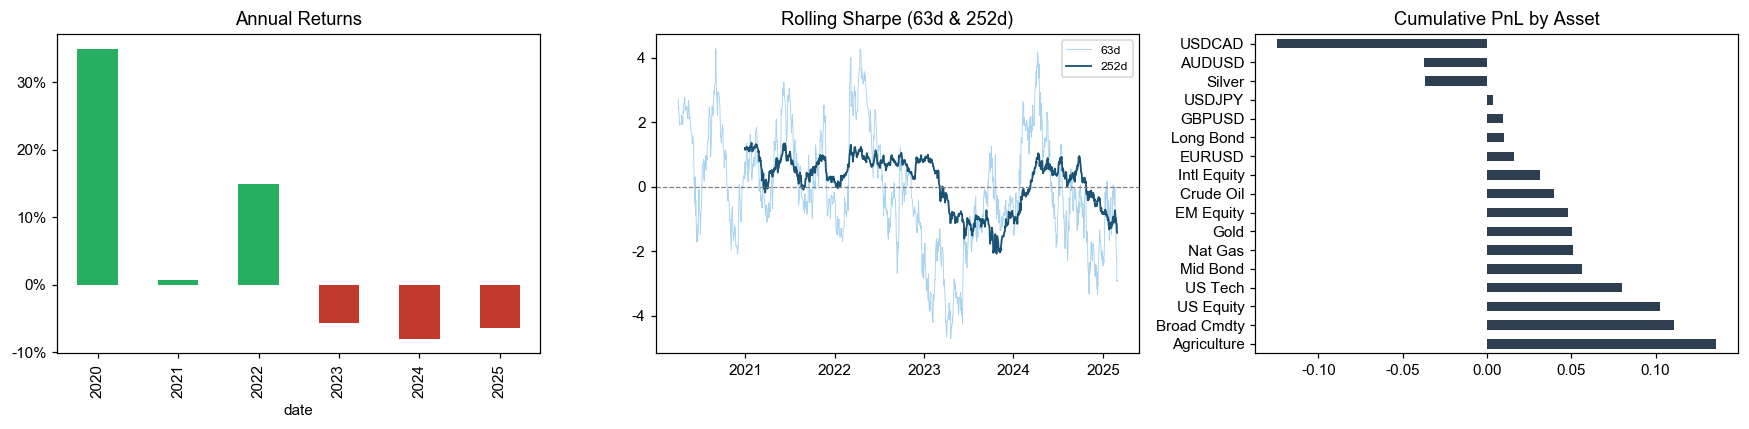

,Return,Vol,Sharpe,MaxDD,Turnover
date,,,,,
2020,34.94%,28.49%,1.19,-14.70%,0.323
2021,0.77%,21.12%,0.14,-12.67%,0.362
2022,14.91%,17.64%,0.88,-12.57%,0.212
2023,-5.65%,6.39%,-0.88,-8.79%,0.152
2024,-7.99%,13.24%,-0.46,-17.59%,0.471
2025,-6.46%,15.63%,-2.03,-9.65%,0.495


In [10]:
def calc_yearly(x):
    return pd.Series({
        'Return': (1 + x).prod() - 1,
        'Vol': x.std() * np.sqrt(252),
        'Sharpe': x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else 0,
        'MaxDD': ((1+x).cumprod() / (1+x).cumprod().cummax() - 1).min(),
        'Turnover': turnover.loc[x.index].mean()
    })

yearly = strat_ret.groupby(strat_ret.index.year).apply(calc_yearly).unstack()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

yearly['Return'].plot.bar(ax=axes[0], color=['#27ae60' if v > 0 else '#c0392b' for v in yearly['Return']])
axes[0].set_title('Annual Returns')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

rolling_sr_63 = strat_ret.rolling(63).apply(lambda x: x.mean()/x.std()*np.sqrt(252), raw=True)
rolling_sr_252 = strat_ret.rolling(252).apply(lambda x: x.mean()/x.std()*np.sqrt(252), raw=True)
axes[1].plot(rolling_sr_63, color='#85c1e9', lw=0.6, alpha=0.7, label='63d')
axes[1].plot(rolling_sr_252, color='#1a5276', lw=1.2, label='252d')
axes[1].axhline(0, color='grey', ls='--', lw=0.8)
axes[1].set_title('Rolling Sharpe (63d & 252d)')
axes[1].legend(fontsize=8)

asset_pnl = (positions.shift(1) * ret).loc[strat_ret.index]
asset_cum_pnl = asset_pnl.cumsum()
top_contributors = asset_cum_pnl.iloc[-1].sort_values(ascending=False)
top_contributors.plot.barh(ax=axes[2], color='#2c3e50')
axes[2].set_title('Cumulative PnL by Asset')

plt.tight_layout()
plt.show()

yearly.style.format({
    'Return': '{:.2%}', 'Vol': '{:.2%}', 'Sharpe': '{:.2f}',
    'MaxDD': '{:.2%}', 'Turnover': '{:.3f}'
})

## 7. Signal Decomposition & Regime Analysis

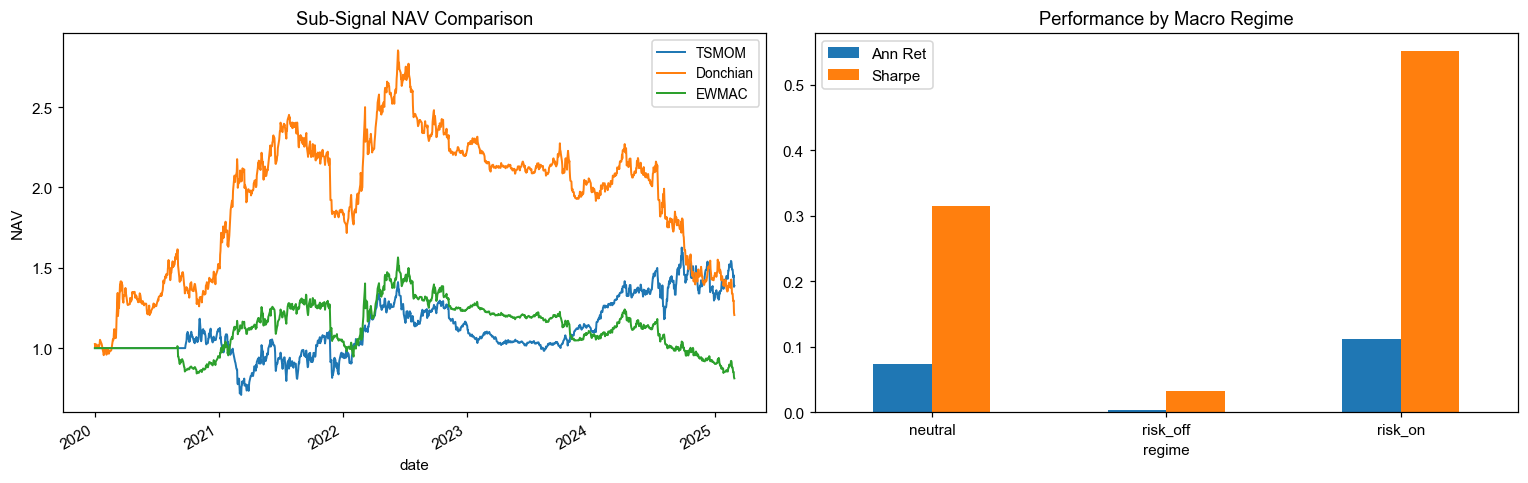

,Ann Ret,Ann Vol,Sharpe,N_days
regime,,,,
neutral,7.29%,23.13%,0.32,490
risk_off,0.30%,9.26%,0.03,452
risk_on,11.16%,20.26%,0.55,416


In [11]:
sig_components = {
    'TSMOM': sig_tsmom, 'Donchian': sig_donch, 'EWMAC': sig_ewmac
}
component_pnl = {}
for name, sig in sig_components.items():
    w = sig * vol_scalar * regime_al.values[:, None]
    w = w.fillna(0).clip(-1, 1)
    r = (w.shift(1) * ret).sum(axis=1)
    component_pnl[name] = r.loc[strat_ret.index]

comp_nav = pd.DataFrame({k: (1+v).cumprod() for k, v in component_pnl.items()})

regime_al_bt = regime.reindex(strat_ret.index).ffill()

def calc_regime(x):
    return pd.Series({
        'Ann Ret': x.mean() * 252, 'Ann Vol': x.std() * np.sqrt(252),
        'Sharpe': x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else 0, 'N_days': len(x)
    })

regime_ret = strat_ret.groupby(regime_al_bt).apply(calc_regime).unstack()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

comp_nav.plot(ax=ax1, lw=1.3)
ax1.set_title('Sub-Signal NAV Comparison')
ax1.set_ylabel('NAV')
ax1.legend(fontsize=9)

regime_ret[['Ann Ret', 'Sharpe']].plot.bar(ax=ax2, rot=0)
ax2.set_title('Performance by Macro Regime')
plt.tight_layout()
plt.show()

regime_ret.style.format({'Ann Ret': '{:.2%}', 'Ann Vol': '{:.2%}', 'Sharpe': '{:.2f}', 'N_days': '{:.0f}'})

## 8. Options Vol Surface — Derivatives Overlay

Snapshot SPY options chain via `list_snapshot_options_chain()`. Analyze implied vol surface and term structure for potential tail hedge / vol carry overlay.

In [12]:
today = datetime.now()
exp_start = (today + timedelta(days=7)).strftime('%Y-%m-%d')
exp_end = (today + timedelta(days=180)).strftime('%Y-%m-%d')

chain = []
try:
    for o in client.list_snapshot_options_chain(
        'SPY',
        params={
            'expiration_date.gte': exp_start,
            'expiration_date.lte': exp_end,
            'strike_price.gte': 500,
            'strike_price.lte': 620,
        },
    ):
        if hasattr(o, 'greeks') and o.greeks and hasattr(o, 'implied_volatility'):
            chain.append({
                'strike': o.details.strike_price,
                'expiry': o.details.expiration_date,
                'type': o.details.contract_type,
                'iv': o.implied_volatility,
                'delta': getattr(o.greeks, 'delta', None),
                'gamma': getattr(o.greeks, 'gamma', None),
                'theta': getattr(o.greeks, 'theta', None),
                'vega': getattr(o.greeks, 'vega', None),
                'oi': getattr(o, 'open_interest', None),
                'last': getattr(o, 'last_trade', {})
            })
    print(f'fetched {len(chain)} contracts')
except Exception as e:
    print(f'options chain error (may require paid plan): {e}')

df_chain = pd.DataFrame(chain) if chain else pd.DataFrame()

fetched 1324 contracts


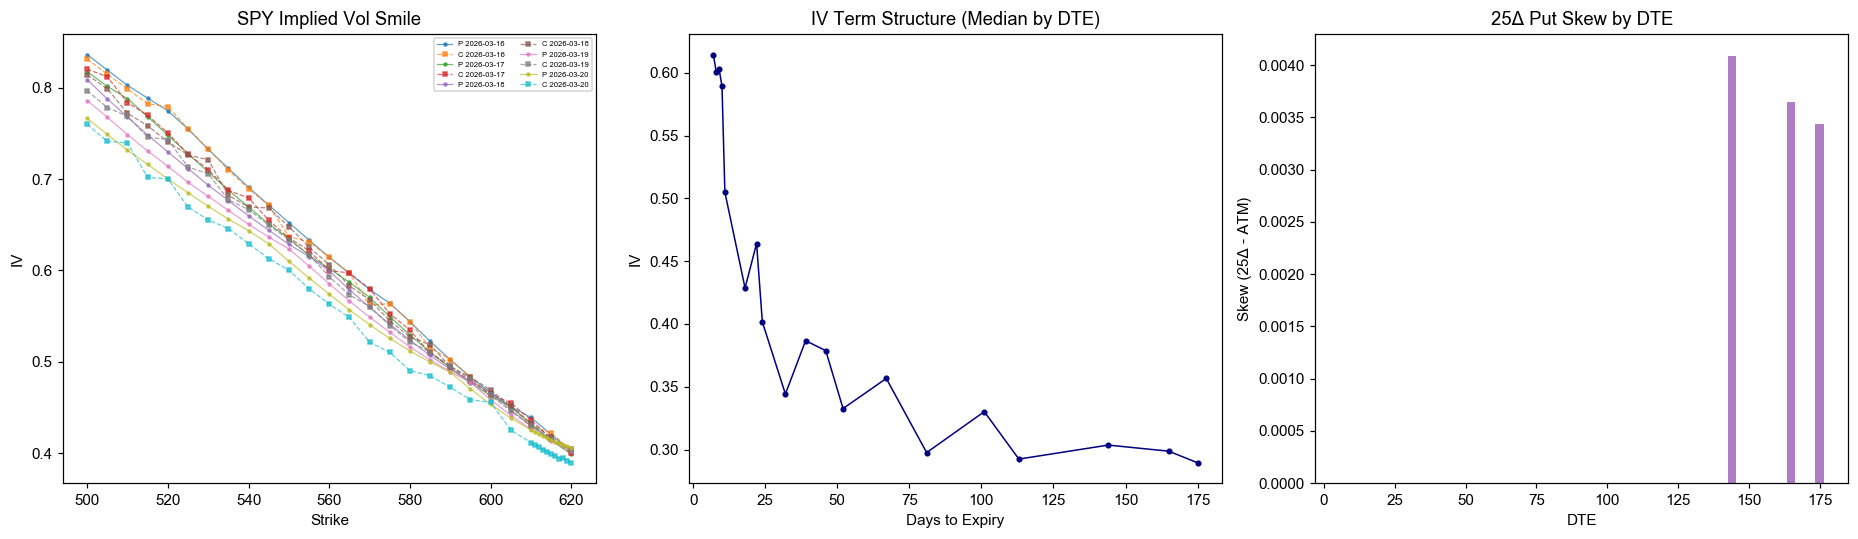

In [13]:
if not df_chain.empty and 'iv' in df_chain.columns:
    df_chain['dte'] = (pd.to_datetime(df_chain['expiry']) - pd.Timestamp(today.date())).dt.days

    puts = df_chain[df_chain['type'] == 'put'].copy()
    calls = df_chain[df_chain['type'] == 'call'].copy()

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    for exp in sorted(df_chain['expiry'].unique())[:5]:
        subset_p = puts[puts['expiry'] == exp]
        subset_c = calls[calls['expiry'] == exp]
        if not subset_p.empty:
            axes[0].plot(subset_p['strike'], subset_p['iv'], 'o-', ms=2, lw=0.8,
                        label=f'P {exp}', alpha=0.7)
        if not subset_c.empty:
            axes[0].plot(subset_c['strike'], subset_c['iv'], 's--', ms=2, lw=0.8,
                        label=f'C {exp}', alpha=0.7)
    axes[0].set_title('SPY Implied Vol Smile')
    axes[0].set_xlabel('Strike')
    axes[0].set_ylabel('IV')
    axes[0].legend(fontsize=5, ncol=2)

    atm_iv = df_chain.groupby('dte')['iv'].median().sort_index()
    axes[1].plot(atm_iv.index, atm_iv.values, 'o-', color='navy', ms=3, lw=1)
    axes[1].set_title('IV Term Structure (Median by DTE)')
    axes[1].set_xlabel('Days to Expiry')
    axes[1].set_ylabel('IV')

    if 'delta' in df_chain.columns:
        skew_by_exp = []
        for exp in df_chain['expiry'].unique():
            p = puts[puts['expiry'] == exp].dropna(subset=['delta', 'iv'])
            if len(p) > 3:
                p25 = p.loc[(p['delta'].abs() - 0.25).abs().idxmin(), 'iv']
                atm = p.loc[(p['delta'].abs() - 0.50).abs().idxmin(), 'iv']
                skew_by_exp.append({'expiry': exp, 'skew_25d': p25 - atm,
                                   'dte': p['dte'].iloc[0]})
        if skew_by_exp:
            sk = pd.DataFrame(skew_by_exp).sort_values('dte')
            axes[2].bar(sk['dte'], sk['skew_25d'], color='#8e44ad', alpha=0.7, width=3)
            axes[2].set_title('25Δ Put Skew by DTE')
            axes[2].set_xlabel('DTE')
            axes[2].set_ylabel('Skew (25Δ - ATM)')

    plt.tight_layout()
    plt.show()
else:
    print('no options data — skipping vol surface visualization')

## 9. Tail Hedge Sizing — Protective Put Budget

Estimate put protection cost as a % of NAV. Size hedge to limit max drawdown to -10% using 25Δ puts, rolling monthly.

In [14]:
if not df_chain.empty:
    puts_30d = puts[(puts['dte'] >= 20) & (puts['dte'] <= 45)].copy()
    if not puts_30d.empty and 'delta' in puts_30d.columns:
        puts_30d = puts_30d.dropna(subset=['delta', 'iv'])
        otm_puts = puts_30d[(puts_30d['delta'].abs() >= 0.15) & (puts_30d['delta'].abs() <= 0.35)]

        if not otm_puts.empty:
            avg_iv = otm_puts['iv'].median()
            avg_dte = otm_puts['dte'].median()

            spy_px = px.iloc[-1, 0] if px.shape[1] > 0 else 560
            bs_approx_pct = avg_iv * np.sqrt(avg_dte / 365) * 0.4

            gross_long = positions.iloc[-1][positions.iloc[-1] > 0].sum()
            hedge_notional = gross_long * spy_px * 100
            monthly_cost_pct = bs_approx_pct

            annual_hedge_budget = monthly_cost_pct * 12

            print(f'--- Tail Hedge Estimate ---')
            print(f'25Δ put avg IV:     {avg_iv:.1%}')
            print(f'avg DTE:            {avg_dte:.0f}d')
            print(f'put cost (% notl):  ~{bs_approx_pct:.2%} per roll')
            print(f'annual hedge drag:  ~{annual_hedge_budget:.2%} of NAV')
            print(f'net Sharpe impact:  ~{-annual_hedge_budget / (strat_ret.std()*np.sqrt(252)):.2f}')
        else:
            print('no suitable 25d puts found')
    else:
        print('insufficient put data for hedge calc')
else:
    print('options data unavailable — using proxy estimate')
    approx_annual_cost = 0.02
    print(f'proxy hedge cost: ~{approx_annual_cost:.1%}/yr (2% OTM put roll, ~25d, monthly)')
    print(f'net return after hedge: {(strat_ret.mean()*252 - approx_annual_cost):.2%}')
    print(f'net Sharpe after hedge: {(strat_ret.mean()*252 - approx_annual_cost)/(strat_ret.std()*np.sqrt(252)):.2f}')

--- Tail Hedge Estimate ---
25Δ put avg IV:     33.3%
avg DTE:            32d
put cost (% notl):  ~3.94% per roll
annual hedge drag:  ~47.33% of NAV
net Sharpe impact:  ~-2.54


## 10. Sensitivity & Robustness

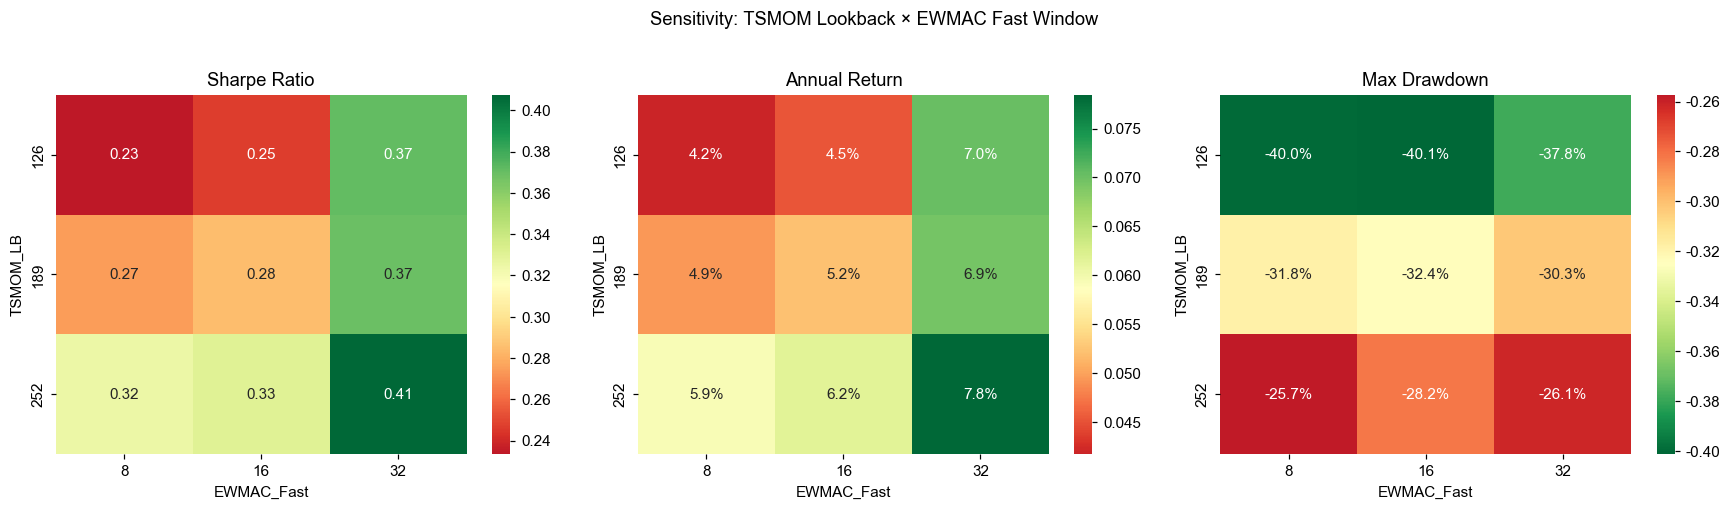

,TSMOM_LB,EWMAC_Fast,Sharpe,Ann_Ret,Vol,MaxDD
0,126,8,0.23,4.17%,17.85%,-40.02%
1,126,16,0.25,4.51%,18.32%,-40.14%
2,126,32,0.37,7.02%,18.93%,-37.82%
3,189,8,0.27,4.93%,17.97%,-31.85%
4,189,16,0.28,5.21%,18.28%,-32.41%
5,189,32,0.37,6.95%,18.83%,-30.25%
6,252,8,0.32,5.93%,18.25%,-25.72%
7,252,16,0.33,6.15%,18.63%,-28.22%
8,252,32,0.41,7.85%,19.26%,-26.14%


In [15]:
param_combos = [(lb, ef) for lb in [126, 189, 252] for ef in [8, 16, 32]]

results = []
for lb, ef in param_combos:
    es = ef * 4
    s1 = tsmom_signal(px, lookback=lb)
    s3 = ewmac_signal(px, fast=ef, slow=es).clip(-2, 2) / 2
    raw = (0.4 * s1.fillna(0) + 0.3 * sig_donch.fillna(0) + 0.3 * s3.fillna(0))
    aw = 0.4 * s1.notna().astype(float) + 0.3 * sig_donch.notna().astype(float) + 0.3 * s3.notna().astype(float)
    raw = raw / aw.replace(0, 1)
    raw = (raw * rsi_filter * macd_filter).clip(-1, 1)

    pos = raw * vol_scalar * regime_al.values[:, None]
    pos = pos.fillna(0)
    ge = pos.abs().sum(axis=1)
    pos = pos.div(ge.clip(lower=3.0), axis=0) * 3.0
    pos[ge <= 3.0] = (raw * vol_scalar * regime_al.values[:, None]).fillna(0)[ge <= 3.0]

    tc = pos.diff().abs().sum(axis=1) * TC_BPS / 10000
    r = (pos.shift(1) * ret).sum(axis=1) - tc
    r = r.loc[r.index >= '2020-01-01']
    sr = r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else 0
    ann = r.mean() * 252
    vol = r.std() * np.sqrt(252)
    md = ((1 + r).cumprod() / (1 + r).cumprod().cummax() - 1).min()
    results.append({'TSMOM_LB': lb, 'EWMAC_Fast': ef,
                    'Sharpe': sr, 'Ann_Ret': ann, 'Vol': vol, 'MaxDD': md})

sens = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

pivot_sr = sens.pivot_table(values='Sharpe', index='TSMOM_LB', columns='EWMAC_Fast')
sns.heatmap(pivot_sr, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[0],
            center=pivot_sr.values.mean())
axes[0].set_title('Sharpe Ratio')

pivot_ret = sens.pivot_table(values='Ann_Ret', index='TSMOM_LB', columns='EWMAC_Fast')
sns.heatmap(pivot_ret, annot=True, fmt='.1%', cmap='RdYlGn', ax=axes[1],
            center=pivot_ret.values.mean())
axes[1].set_title('Annual Return')

pivot_dd = sens.pivot_table(values='MaxDD', index='TSMOM_LB', columns='EWMAC_Fast')
sns.heatmap(pivot_dd, annot=True, fmt='.1%', cmap='RdYlGn_r', ax=axes[2],
            center=pivot_dd.values.mean())
axes[2].set_title('Max Drawdown')

plt.suptitle('Sensitivity: TSMOM Lookback × EWMAC Fast Window', y=1.02)
plt.tight_layout()
plt.show()

sens.style.format({'Sharpe': '{:.2f}', 'Ann_Ret': '{:.2%}', 'Vol': '{:.2%}', 'MaxDD': '{:.2%}'})

### Position Export

In [ ]:
import os, requests as _req
from datetime import datetime as _dt

_fmp_key = cfg['keys']['fmp_api_key']

_name_to_ticker = {v: k for k, v in etf_tickers.items()}
_fx_etf_map = {
    'EURUSD': ('FXE',  1), # long EURUSD: long FXE
    'GBPUSD': ('FXB',  1), # long GBPUSD: long FXB
    'USDJPY': ('FXY', -1), # long USDJPY: short FXY (FXY = long JPY)
    'AUDUSD': ('FXA',  1), # long AUDUSD: long FXA
    'USDCAD': ('FXC', -1), # long USDCAD: short FXC (FXC = long CAD)
    'NZDUSD': ('NZDUSD', 1), # no liquid FX ETF — keep as-is
}
for fx_name, (etf, _) in _fx_etf_map.items():
    _name_to_ticker[fx_name] = etf

def _fmp_ids(tickers, api_key):
    out = {}
    for t in tickers:
        try:
            r = _req.get(f"https://financialmodelingprep.com/stable/profile?symbol={t}&apikey={api_key}", timeout=10)
            d = r.json()
            out[t] = (d[0].get("cusip","") if d else "", d[0].get("isin","") if d else "")
        except Exception:
            out[t] = ("", "")
    return out

day = _dt.now().strftime("%Y%m%d")
latest = positions.iloc[-1]
latest = latest[latest.abs() > 1e-6]

raw_names = latest.index.tolist()
tks = [_name_to_ticker.get(n, n) for n in raw_names]
raw_wts = latest.values / latest.abs().values.sum()
signs = np.array([_fx_etf_map[n][1] if n in _fx_etf_map else 1 for n in raw_names])
wts = raw_wts * signs

ids = _fmp_ids(tks, _fmp_key)

df_pos = pd.DataFrame({
    "ticker": tks,
    "cusip": [ids[t][0] for t in tks],
    "isin": [ids[t][1] for t in tks],
    "weight": wts,
    "order_time": "MOC",
    "order_type": "default"
})

out_dir = f"../execution_main/trading_log/{day}"
os.makedirs(out_dir, exist_ok=True)
df_pos.to_csv(f"{out_dir}/strategy_ctaDerivatives_weight.csv", index=False)
print(f"→ {out_dir}/strategy_ctaDerivatives_weight.csv  ({len(df_pos)} rows)")
df_pos